# 1. Objective

The goal of this notebook is to identify new candidate signals that are more stable across time and market conditions than the feature set used previously. Instead of starting with a complex model, I begin by engineering economically sensible signals, testing them individually, and screening for robustness before moving to model-based validation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.data_loader import (split_features_target, 
                             time_based_split, 
                             get_benchmark_returns)
from src.backtest import (generate_positions_from_proba,
                          strategy_returns_from_positions,
                          cumulative_returns,
                          evaluate_strategy)

# 2. Load preprocessed data

In [6]:
project_root = Path.cwd().parent
nb02_path = project_root / "data" / "processed" / "notebook_02_data_prep"
nb05_path = project_root / "data" / "processed" / "notebook_05_model_outputs"
ML_dataset = pd.read_csv(nb05_path / "ML_dataset.csv", index_col=0)
clean_close_prices = pd.read_csv(nb02_path / "clean_close_prices.csv", index_col=0)
print("ML_dataset shape:", ML_dataset.shape)
print("clean_close_prices shape:", clean_close_prices.shape)

ML_dataset shape: (2016, 311)
clean_close_prices shape: (2080, 31)


# 3. Define features/ target and split based on time

In [7]:
X, y = split_features_target (ML_dataset)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X_train, X_test, y_train, y_test = time_based_split(X, y)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training targets:", len(y_train))
print("Testing targets:", len(y_test))

Feature shape: (2016, 310)
Target shape: (2016,)

Training samples: 1612
Testing samples: 404
Training targets: 1612
Testing targets: 404


# 4. Benchmark Returns (Aligned to Test Period)

In [9]:
benchmark_returns = get_benchmark_returns(price_df=clean_close_prices,
                                          tickers="SPY",
                                          index=X_test.index)
benckmark_cum_returns = cumulative_returns(benchmark_returns)
benchmark_returns.head()

,SPY
Date,
2024-08-26,-0.002384
2024-08-27,0.001373
2024-08-28,-0.005805
2024-08-29,0.000090
2024-08-30,0.009546


# 5. Build candidate signals from existing features

In [12]:
candidate_signals = pd.DataFrame(index=X_test.index)
available_features = X_test.columns.tolist()
wishlist_features = ["MRK_ret", "MRK_mom5", "MRK_mom20", "KO_mom5", "KO_mom20", "CVX_mom5", "XOM_vol20", "MRK_vol20", "MRK_trend", "KO_trend"]
existing_features = [features for features in wishlist_features if features in available_features]
candidate_signals = X_test[existing_features].copy()
candidate_signals.describe().T

,count,mean,std,min,25%,50%,75%,max
MRK_ret,404.0,0.000348,0.017086,-0.090690,-0.008821,-0.000111,0.010444,0.073871
MRK_mom5,404.0,0.002030,0.040430,-0.134182,-0.023338,0.000100,0.023991,0.153479
MRK_mom20,404.0,0.006758,0.074751,-0.186769,-0.043562,0.006952,0.052807,0.224755
KO_mom5,404.0,0.002082,0.023412,-0.056012,-0.012462,-0.000977,0.016440,0.096907
KO_mom20,404.0,0.008982,0.049791,-0.123509,-0.023122,-0.000070,0.035183,0.162422
CVX_mom5,404.0,0.005319,0.033184,-0.187407,-0.012274,0.009354,0.025605,0.092188
XOM_vol20,404.0,0.014247,0.004249,0.007061,0.011452,0.013400,0.015852,0.030153
MRK_vol20,404.0,0.016319,0.005084,0.007500,0.012508,0.014741,0.019519,0.026984
MRK_trend,404.0,0.509901,0.500522,0.000000,0.000000,1.000000,1.000000,1.000000
KO_trend,404.0,0.524752,0.500006,0.000000,0.000000,1.000000,1.000000,1.000000


# 6. Generate positions from candidate signals

In [16]:
candidate_signal_results =[]
for signal_name in candidate_signals.columns:
    signal = candidate_signals[signal_name]
    candidate_positions, upper_threshold, lower_threshold = generate_positions_from_proba(probabilities=signal,
                                                                                         upper_quantile=0.8,
                                                                                         lower_quantile=0.2)
    net_candidate_returns = strategy_returns_from_positions(positions=candidate_positions,
                                                            returns=benchmark_returns,
                                                            lag=1,
                                                            cost_per_trade=0.0005)
    summary = evaluate_strategy(net_candidate_returns, positions=candidate_positions)
    summary["Signal"] = signal_name
    summary["Upper Threshold"] = upper_threshold
    summary["Lower Threshold"] = lower_threshold
    candidate_signal_results.append(summary)
candidate_signal_results = pd.DataFrame(candidate_signal_results)
candidate_signal_results = candidate_signal_results.set_index("Signal").sort_values("Sharpe Ratio", ascending=False)
candidate_signal_results

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Rate,Exposure Rate,Turnover,Upper Threshold,Lower Threshold
Signal,,,,,,,,,
MRK_vol20,0.017183,0.089583,0.191815,-0.164853,0.458101,0.399504,0.089330,0.022093,0.011819
XOM_vol20,-0.010460,0.132553,-0.078914,-0.125184,0.436464,0.401985,0.101737,0.016340,0.011046
MRK_mom20,-0.028198,0.142281,-0.198187,-0.160971,0.422460,0.399504,0.119107,0.069184,-0.056721
CVX_mom5,-0.068473,0.135703,-0.504576,-0.221739,0.364929,0.401985,0.250620,0.029317,-0.016417
KO_mom5,-0.111011,0.128966,-0.860779,-0.253845,0.357466,0.399504,0.300248,0.020024,-0.016431
KO_trend,-0.151630,0.173454,-0.874179,-0.290667,0.476427,1.000000,0.054591,1.000000,0.000000
MRK_trend,-0.158081,0.173356,-0.911887,-0.318573,0.471464,1.000000,0.024814,1.000000,0.000000
MRK_mom5,-0.117364,0.120867,-0.971021,-0.197538,0.334862,0.401985,0.282878,0.030742,-0.028235
KO_mom20,-0.156358,0.133385,-1.172229,-0.292044,0.407035,0.399504,0.181141,0.044760,-0.027276


# 7. Plot top signal based on Sharpe Ratio

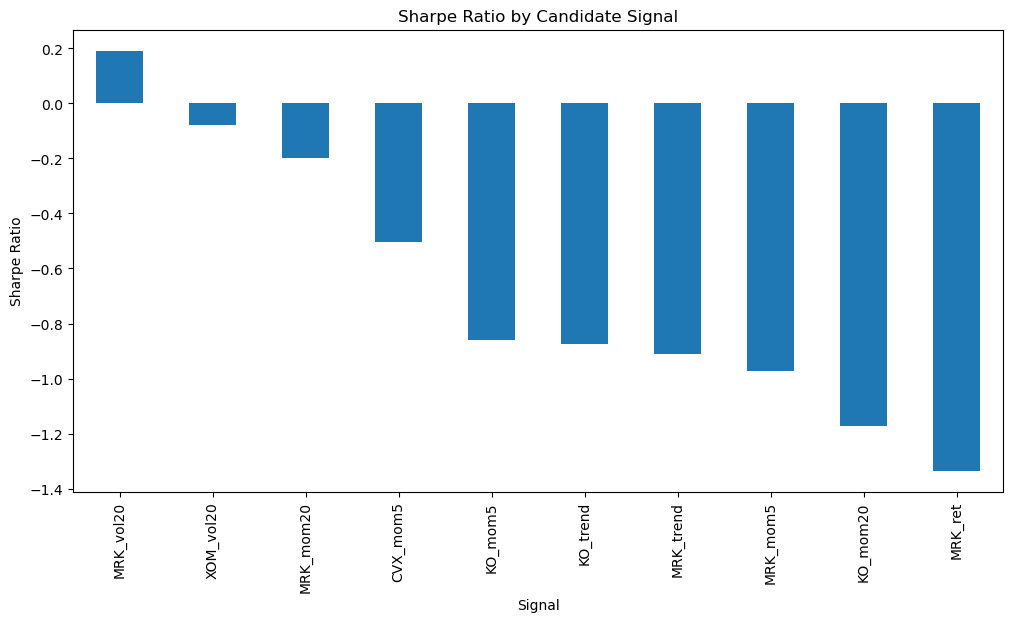

In [22]:
candidate_signal_results["Sharpe Ratio"].plot(kind="bar", figsize=(12, 6))
plt.title("Sharpe Ratio by Candidate Signal")
plt.ylabel("Sharpe Ratio")
plt.show()

 # 8. Midpoint Conclusion — Signal Screening

The initial candidate signal set did not perform as expected.

Only MRK_vol20 showed a marginally positive Sharpe ratio, while all other signals were weak or negative, indicating that the majority of features lack predictive power.

This suggests that the current approach—selecting signals based on intuition or prior assumptions—is insufficient. The observed performance confirms that the model failure in earlier steps was primarily driven by poor signal quality rather than model choice.

Given the lack of robust standalone signals, proceeding to stress testing at this stage would not be meaningful. Instead, the workflow is adjusted to re-extract and systematically construct a new set of candidate signals, with a focus on improving signal strength and stability before further evaluation.

# 9. Re-extract signals using signal families

In [25]:
windows = [3, 5, 10, 20]          
for w in windows:                     # Momentum
    candidate_signals[f'mom_{w}'] = X_test["MRK_ret"].rolling(w).mean()

for w in windows:                     # Volatility
    candidate_signals[f'vol_{w}'] = X_test["MRK_ret"].rolling(w).std()

for w in windows:                     # Mean Reversion
    rolling_mean = X_test["MRK_ret"].rolling(w).mean()
    rolling_std = X_test["MRK_ret"].rolling(w).std()
    candidate_signals[f'zscore_{w}'] = (X_test["MRK_ret"] - rolling_mean) / rolling_std

for w in windows:                     # Moving Average
    moving_avg = X_test["MRK_ret"].rolling(w).mean()
    candidate_signals[f'trend_{w}'] = (moving_avg > 0).astype(int)

candidate_signals = candidate_signals.dropna()
candidate_signals.head()

,MRK_ret,MRK_mom5,MRK_mom20,KO_mom5,KO_mom20,CVX_mom5,XOM_vol20,MRK_vol20,MRK_trend,KO_trend,...,vol_10,vol_20,zscore_3,zscore_5,zscore_10,zscore_20,trend_3,trend_5,trend_10,trend_20
Date,,,,,,,,,,,,,,,,,,,,,
2024-09-23,-0.013143,-0.019752,-0.001684,-0.005132,0.034844,0.038356,0.015327,0.011505,0,1,...,0.010667,0.011505,-0.665429,-1.156124,-1.317358,-1.140537,0,0,1,0
2024-09-24,-0.005794,-0.028151,-0.004652,-0.006546,0.013820,0.028171,0.014528,0.011562,0,1,...,0.010872,0.011562,0.108574,-0.017068,-0.569622,-0.486479,0,0,1,0
2024-09-25,-0.002001,-0.032957,-0.008604,-0.004181,0.006152,0.000069,0.015011,0.011557,0,1,...,0.010724,0.011557,0.878867,0.819837,-0.255175,-0.141195,0,0,1,0
2024-09-26,-0.014294,-0.035315,-0.030267,0.011045,0.001944,-0.020691,0.015320,0.011792,0,1,...,0.011590,0.011792,-1.101032,-1.132001,-1.132841,-1.087581,0,0,0,0
2024-09-27,0.005306,-0.029700,-0.025620,0.002094,0.003222,-0.001304,0.016248,0.011883,0,1,...,0.011591,0.011883,0.905453,1.390675,0.558053,0.550004,0,0,0,0


# 10. Test signal families

In [29]:
test_results = []
for family in candidate_signals.columns:
    signal = candidate_signals[family]
    positions, upper_threshold, lower_threshold = generate_positions_from_proba(probabilities=signal, upper_quantile=0.8, lower_quantile=0.2)
    net_ret = strategy_returns_from_positions(positions=positions, returns=benchmark_returns, lag=1, cost_per_trade=0.0005)
    summary = evaluate_strategy(returns=net_ret, positions=positions)
    summary["Signal"] = family
    test_results.append(summary)
test_results = pd.DataFrame(test_results)
test_results = test_results.sort_values("Sharpe Ratio", ascending=False)
test_results

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Rate,Exposure Rate,Turnover,Signal
17,0.008291,0.088675,0.093502,-0.124905,0.441176,0.398438,0.088542,vol_20
7,0.008291,0.088675,0.093502,-0.124905,0.441176,0.398438,0.088542,MRK_vol20
25,0.013555,0.175055,0.077434,-0.188061,0.500000,1.000000,0.171875,trend_20
6,-0.005466,0.134169,-0.040741,-0.119458,0.436782,0.401042,0.111979,XOM_vol20
15,-0.006989,0.124566,-0.056106,-0.084730,0.398990,0.398438,0.257812,vol_5
12,-0.026616,0.144960,-0.183609,-0.159904,0.410811,0.401042,0.166667,mom_10
16,-0.025240,0.136495,-0.184913,-0.109812,0.401099,0.398438,0.158854,vol_10
24,-0.038026,0.175195,-0.217052,-0.153180,0.489583,1.000000,0.260417,trend_10
13,-0.033371,0.145160,-0.229889,-0.160632,0.424581,0.401042,0.130208,mom_20
2,-0.041072,0.145308,-0.282654,-0.164661,0.416667,0.401042,0.135417,MRK_mom20


# 11. Filter for strong signals

In [32]:
strong_signals = test_results[(test_results["Sharpe Ratio"] > 0.5) & (test_results["Max Drawdown"] > -0.3)]
strong_signals = pd.DataFrame(strong_signals)
strong_signals

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Rate,Exposure Rate,Turnover,Signal


# Midpoint Conclusion - No individual strong signal

# 12. Combine less weak signals

In [45]:
combined_signal = candidate_signals[["vol_20", "MRK_vol20", "trend_20"]].mean(axis=1)
positions, upper_threshold, lower_threshold = generate_positions_from_proba(probabilities=combined_signal, upper_quantile=0.8, lower_quantile=0.2)
net_ret = strategy_returns_from_positions(positions=positions, returns=benchmark_returns, lag=1, cost_per_trade=0.0005)
combined_summary = evaluate_strategy(returns=net_ret, positions=positions)
combined_summary["Signal"] = "combined_vol20_MRKvol20_trend20"
combined_results = pd.DataFrame([combined_summary])
combined_results

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Hit Rate,Exposure Rate,Turnover,Signal
0,-0.03884,0.076328,-0.508857,-0.083384,0.425287,0.398438,0.106771,combined_vol20_MRKvol20_trend20


# 13. Conclusion

In this notebook, I re-extracted a smaller, more controlled set of candidate signals to avoid the noise observed in earlier models. I tested individual signals, ranked them by performance, and attempted to combine weaker signals to improve robustness.

The results show that most individual signals remain weak or unstable, and combining them does not produce meaningful improvement. No candidate demonstrates consistent or economically meaningful predictive power after evaluation.

This indicates that the limitation is not in model complexity or threshold selection, but in the underlying signal construction itself. As a result, I stop further optimization on this signal set.

The next step is to shift focus to developing new signal families with stronger economic intuition and more robust predictive structure before reintroducing them into the modeling pipeline.